In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('default')

In [3]:
df = pd.read_csv("Amazon.csv")

df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [4]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (100000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  object 
 1   OrderDate      100000 non-null  object 
 2   CustomerID     100000 non-null  object 
 3   CustomerName   100000 non-null  object 
 4   ProductID      100000 non-null  object 
 5   ProductName    100000 non-null  object 
 6   Category       100000 non-null  object 
 7   Brand          100000 non-null  object 
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  object 
 15  OrderStatus    100000 non-null  object 
 16  City           100000 non-null  object 
 17  State     

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


In [5]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

df['Month'] = df['OrderDate'].dt.month
df['Year'] = df['OrderDate'].dt.year

df['NetProfit'] = (
    (df['Quantity'] * df['UnitPrice'])
    - (df['Quantity'] * df['UnitPrice'] * df['Discount'])
    - df['Tax']
    - df['ShippingCost']
)

df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID,Month,Year,NetProfit
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967,1,2023,319.6800
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298,12,2023,217.9615
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908,5,2022,81.1010
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164,7,2023,125.7650
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,...,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411,2,2023,725.5600


In [6]:
monthly_sales = df.groupby('Month')['TotalAmount'].sum().reset_index()

monthly_sales

,Month,TotalAmount
0,1,7883801.27
1,2,6931724.49
2,3,7766527.73
3,4,7646203.22
4,5,7864283.27
5,6,7654636.75
6,7,7737925.51
7,8,7890598.37
8,9,7558970.85
9,10,7654243.32


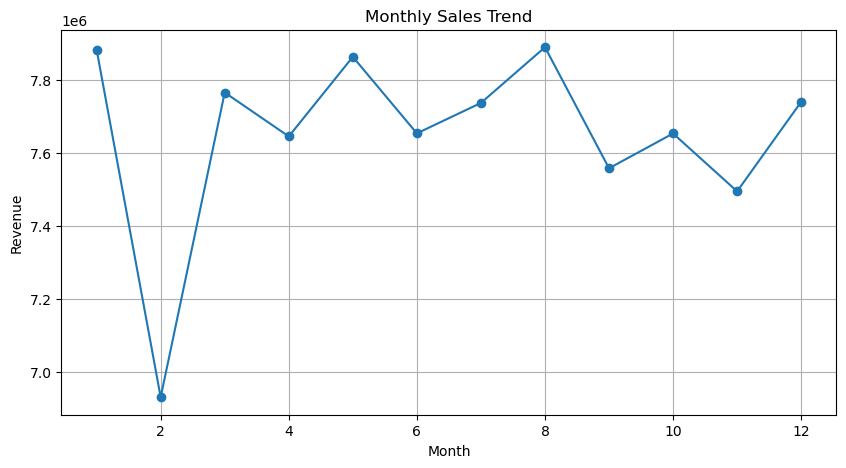

In [7]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales['Month'],
    monthly_sales['TotalAmount'],
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [8]:
category_sales = (
    df.groupby('Category')['TotalAmount']
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Home & Kitchen       15163939.36
Name: TotalAmount, dtype: float64

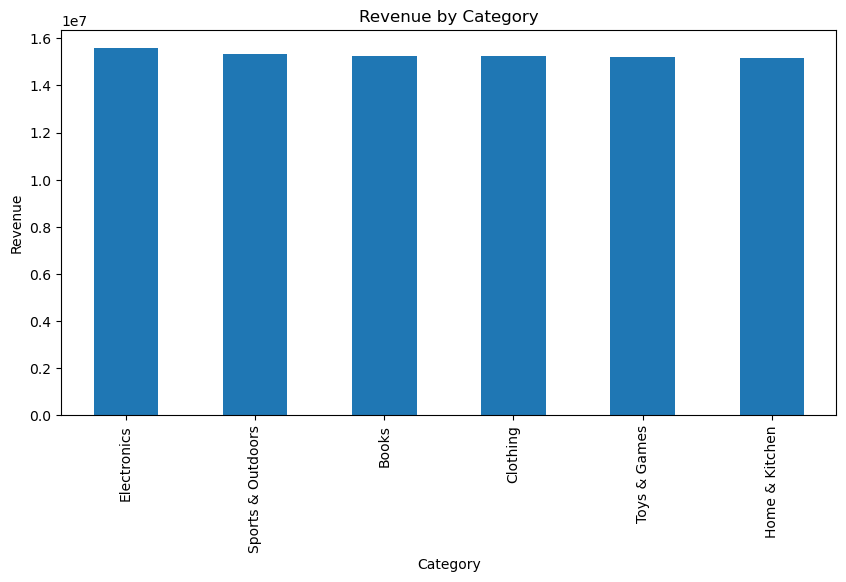

In [9]:
plt.figure(figsize=(10,5))

category_sales.plot(kind='bar')

plt.title("Revenue by Category")
plt.ylabel("Revenue")

plt.show()

In [10]:
product_sales = (
    df.groupby('ProductName')['TotalAmount']
    .sum()
    .sort_values()
)

dead_stock = product_sales.head(
    int(len(product_sales)*0.20)
)

dead_stock

ProductName
Children's Book     1738112.57
Backpack            1749971.14
Desk Plant          1759672.62
USB-C Charger       1763075.26
Car Charger         1779795.27
Fitness Band        1784149.50
External HDD 2TB    1786108.33
Graphic Tablet      1786772.26
T-Shirt             1787855.05
Sunglasses          1788111.81
Name: TotalAmount, dtype: float64

In [11]:
dead_stock.head(10)

ProductName
Children's Book     1738112.57
Backpack            1749971.14
Desk Plant          1759672.62
USB-C Charger       1763075.26
Car Charger         1779795.27
Fitness Band        1784149.50
External HDD 2TB    1786108.33
Graphic Tablet      1786772.26
T-Shirt             1787855.05
Sunglasses          1788111.81
Name: TotalAmount, dtype: float64

In [12]:
product_revenue = (
    df.groupby('ProductName')['TotalAmount']
    .sum()
    .sort_values(ascending=False)
)

cumulative_percent = (
    product_revenue.cumsum()
    / product_revenue.sum()
    * 100
)

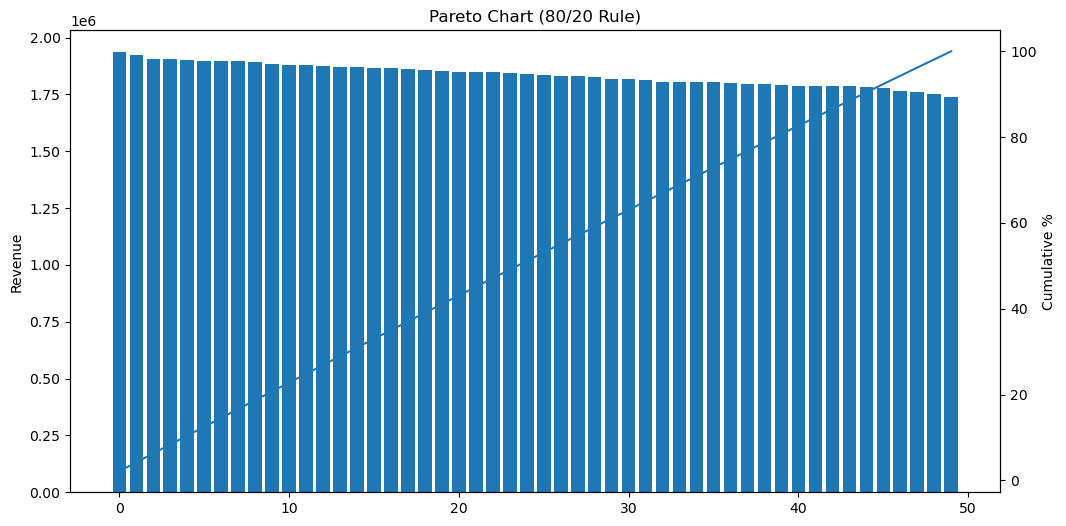

In [13]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(
    range(len(product_revenue)),
    product_revenue.values
)

ax1.set_ylabel("Revenue")

ax2 = ax1.twinx()

ax2.plot(
    range(len(product_revenue)),
    cumulative_percent.values
)

ax2.set_ylabel("Cumulative %")

plt.title("Pareto Chart (80/20 Rule)")

plt.show()

In [14]:
monthly_category = (
    df.groupby(['Month','Category'])
    ['TotalAmount']
    .sum()
    .reset_index()
)

monthly_category.head()

,Month,Category,TotalAmount
0,1,Books,1308642.44
1,1,Clothing,1294680.54
2,1,Electronics,1372357.03
3,1,Home & Kitchen,1306233.74
4,1,Sports & Outdoors,1320461.52


In [15]:
electronics = monthly_category[
    monthly_category['Category'] == 'Electronics'
].copy()

electronics

,Month,Category,TotalAmount
2,1,Electronics,1372357.03
8,2,Electronics,1187415.16
14,3,Electronics,1354055.87
20,4,Electronics,1284105.93
26,5,Electronics,1408170.00
32,6,Electronics,1194835.09
38,7,Electronics,1282894.69
44,8,Electronics,1322149.64
50,9,Electronics,1271494.44
56,10,Electronics,1320530.73


In [16]:
electronics = electronics.sort_values('Month')

electronics['TimeIndex'] = range(
    1,
    len(electronics)+1
)

electronics

,Month,Category,TotalAmount,TimeIndex
2,1,Electronics,1372357.03,1
8,2,Electronics,1187415.16,2
14,3,Electronics,1354055.87,3
20,4,Electronics,1284105.93,4
26,5,Electronics,1408170.00,5
32,6,Electronics,1194835.09,6
38,7,Electronics,1282894.69,7
44,8,Electronics,1322149.64,8
50,9,Electronics,1271494.44,9
56,10,Electronics,1320530.73,10


In [17]:
X = electronics[['TimeIndex']]
y = electronics['TotalAmount']

model = LinearRegression()

model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
next_month = pd.DataFrame({
    'TimeIndex':[electronics['TimeIndex'].max()+1]
})

prediction = model.predict(next_month)

print("Predicted Next Month Sales:")
print(prediction[0])

Predicted Next Month Sales:
1290091.8468181817


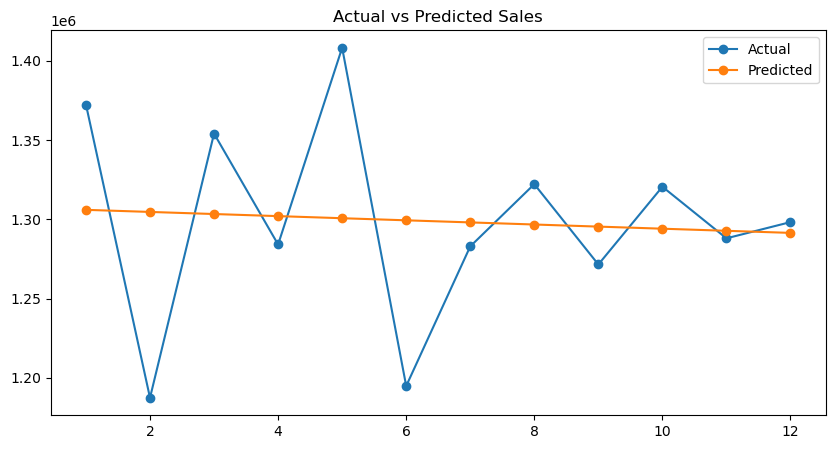

In [19]:
electronics['Predicted'] = model.predict(X)

plt.figure(figsize=(10,5))

plt.plot(
    electronics['Month'],
    electronics['TotalAmount'],
    marker='o',
    label='Actual'
)

plt.plot(
    electronics['Month'],
    electronics['Predicted'],
    marker='o',
    label='Predicted'
)

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.show()

In [20]:
print("Top Revenue Categories")
print(category_sales.head())

print("\nDead Stock Products")
print(dead_stock.head(10))

print("\nPredicted Next Month Electronics Sales")
print(prediction[0])

Top Revenue Categories
Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Name: TotalAmount, dtype: float64

Dead Stock Products
ProductName
Children's Book     1738112.57
Backpack            1749971.14
Desk Plant          1759672.62
USB-C Charger       1763075.26
Car Charger         1779795.27
Fitness Band        1784149.50
External HDD 2TB    1786108.33
Graphic Tablet      1786772.26
T-Shirt             1787855.05
Sunglasses          1788111.81
Name: TotalAmount, dtype: float64

Predicted Next Month Electronics Sales
1290091.8468181817
